In [139]:
import numpy as np
import qiskit 
from qiskit.circuit import QuantumRegister, QuantumCircuit, Parameter
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator, StatevectorSampler

import matplotlib.pyplot as plt

import pandas as pd

import scipy.optimize as opt

Outline for this project

* take notes on the VQLS paper
    - implement VQLS on some basic scale

* scale up the qubits/simulate on IBM QPU
* use cuda-q to simulate too maybe
* learn HPC to run training loop

* find barren plateaus?
    * DLA!


# Simple 3-qubit example

$ A = c_0 A_0 + c_1 A_1 + c_2 A_2 \\ A = I + 0.2 X_0 Z_1 + 0.2 X_0 $

$ |b \rangle = U | 000 \rangle = H_0 H_1 H_2 |000 \rangle $

A simple ansatz can be used:

$ V(\alpha) = R_y(\alpha_0) \otimes R_y(\alpha_1) \otimes R_y(\alpha_2) \\ V(\alpha)|0 \rangle = |x \rangle$


ParameterView([Parameter(α_0), Parameter(α_1), Parameter(α_2)])

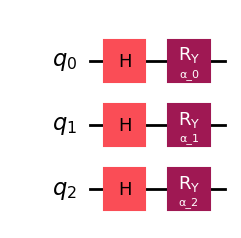

In [140]:
n_qubits = 3
n_shots = 10 ** 6

total_qubits = n_qubits + 1
ancilla_idx = n_qubits

q_delta = 0.001 # intial spread of random quantum weights
rng_seed = 23498

# U gate
Ub = qiskit.QuantumCircuit(3)
for i in range(n_qubits):
    Ub.h(i)

Ub.draw('mpl')

# generate controlled A gate:

coefficients = np.array([1.0, 0.2, 0.2])

def controlled_A(i):
    circuit = qiskit.QuantumCircuit(total_qubits)

    match(i):
        case 0:
            pass # identity
        case 1:
            circuit.cx(ancilla_idx, 0)
            circuit.cz(ancilla_idx, 1)
        case 2:
            circuit.cx(ancilla_idx, 0)  

    return circuit

# Variational form

V = qiskit.QuantumCircuit(n_qubits)
α_in = [Parameter(f'α_{i}') for i in range(n_qubits)]

for i in range(n_qubits):
    V.h(i)
for i in range(n_qubits):
    V.ry(α_in[i], i)

display(V.parameters)

V.draw('mpl')

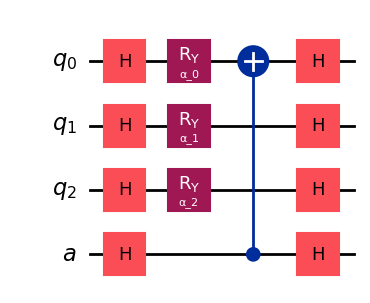

array([[1.]])

In [141]:
# hadamard test

def local_hadamard_test(weights, l: int=None, lp: int=None, j: int=None, part: str=""):
    system = QuantumRegister(3, name='q')
    ancilla = QuantumRegister(1, name='a')
    circuit = QuantumCircuit(system, ancilla)

    # first hadamard for the hadamard test
    circuit.h(ancilla_idx)

    if part.lower() == 'im':
        # phase shift by -pi/2
        θ = -np.pi / 2

        circuit.u1(θ, ancilla_idx)
        circuit.x(ancilla_idx)
        circuit.u1(θ, ancilla_idx)
        circuit.x(ancilla_idx)

    # apply ansatz
    circuit.compose(V, inplace=True)

    circuit.compose(controlled_A(l), inplace=True)

    # typically would be the adjoint of U but U_dag = U in this case
    circuit.compose(Ub, inplace=True)

    circuit.compose(controlled_A(lp), inplace=True)

    circuit.h(ancilla_idx)

    observables = [[SparsePauliOp(["IIIZ"])]]
    estimator = StatevectorEstimator()

    pub = (circuit, observables, weights)
    job = estimator.run([pub])

    evs = job.result()[0].data.evs

    return evs, circuit


evs, circuit = local_hadamard_test(np.zeros(n_qubits), l=2)

display(circuit.draw('mpl'))
evs


Now we need to run the local hadamard test to get the real and imaginary parts of $ \mu _{l,l',j}$

In [142]:
# get the real and imaginary parts of μ 
def mu(weights, l: int=None, lp: int=None, j: int=None):
    mu_real = local_hadamard_test(weights, l=l, lp=lp, part='real')[0]
    mu_imag = local_hadamard_test(weights, l=l, lp=lp, part='imag')[0]

    return mu_real + 1.0j * mu_imag

Define the local cost function to estimate ψ
$$| \psi \rangle = \langle x | A^\dagger A | x \rangle $$

$$C_L = \frac{1}{2} - \frac{1}{2n} \frac{\sum c_l c_{l'}^* \langle 0 | V^\dagger A_{l'}^\dagger U Z_j U^\dagger A_l V | 0 \rangle}{\sum c_l c_{l'}^* \langle 0 | V^\dagger A_{l'}^\dagger  A_l V | 0 \rangle}$$


In [143]:
# define the norm
def norm(weights):
    norm = 0.0

    for l in range(0, len(coefficients)):
        for lp in range(0, len(coefficients)):
            norm += coefficients[l] * np.cong(coefficients[lp]) * mu(weights, l, lp, -1)

    return abs(norm)

# define the local cost function
def local_cost(weights):
    mu_sum = 0.0

    for l in range(0, len(coefficients)):
        for lp in range(0, len(coefficients)):
            for j in range(0, n_qubits):
                mu_sum += coefficients[l] * np.conj(coefficients[lp]) * mu(weights, l, lp, j)

    mu_sum = abs(mu_sum)
    return mu_sum


In [144]:
np.random.seed(rng_seed)
α = q_delta * np.random.randn(n_qubits)
α

array([ 0.00180785, -0.00095089,  0.00012278])

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 4.425418796743034e-08
        x: [ 1.571e+00 -9.248e-04  1.054e-04]
      nit: 1
      jac: [ 1.448e-07  3.161e-08  1.291e-08]
 hess_inv: [[1 0 0]
            [0 1 0]
            [0 0 1]]
     nfev: 100
     njev: 25

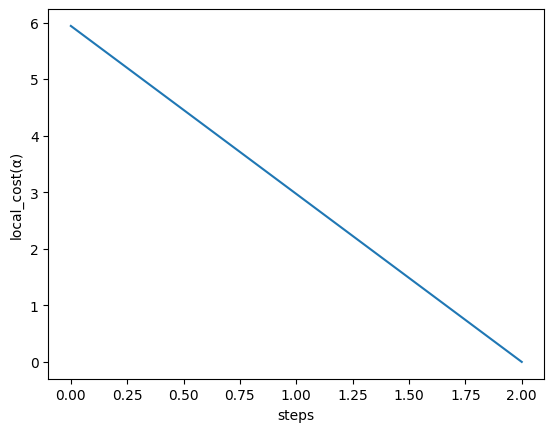

In [145]:
history = []
def log_step(xk):
    cost = local_cost(xk)
    history.append(np.copy(cost))

# history.append(np.copy())
log_step(α)

res = opt.minimize(local_cost, α, callback=log_step)

xs = np.linspace(0, 2, len(history))

plt.plot(xs, [h[0][0] for h in history])
plt.xlabel("steps")
plt.ylabel("local_cost(α)")
res


# Check solution

$ A = c_0 A_0 + c_1 A_1 + c_2 A_2 \\ A = I + 0.2 X_0 Z_1 + 0.2 X_0 $

$ |b \rangle = U | 000 \rangle = H_0 H_1 H_2 |000 \rangle $

$ V(\alpha) = R_y(\alpha_0) \otimes R_y(\alpha_1) \otimes R_y(\alpha_2) \\ V(\alpha)|0 \rangle = |x \rangle$


In [ ]:
# classically compute
I = np.eye(2)
Z = np.array([
    [1, 0],
    [0, -1]
])
X = np.array([
    [0, 1],
    [1, 0]
])

A_0 = np.eye(8) # 2^3
A_1 = coefficients[1] * np.kron(np.kron(X, Z), I)
A_2 = coefficients[2] * np.kron(np.kron(X, I), I)
A = A_0 + A_1 + A_2

b = np.ones(8) / np.sqrt(8) # total superposition (all hadamard gates)
x = np.linalg.solve(A, b)

print("A:")
print(A)

print("\nb:")
print(b)

print("\nx:")
print(x)

x_norm = np.linalg.norm(x)
print("norm of x:", x_norm)

xhat = (x / x_norm)**2
print(f"\nxhat: {xhat}")


A:
[[1.  0.  0.  0.  0.4 0.  0.  0. ]
 [0.  1.  0.  0.  0.  0.4 0.  0. ]
 [0.  0.  1.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  1.  0.  0.  0.  0. ]
 [0.4 0.  0.  0.  1.  0.  0.  0. ]
 [0.  0.4 0.  0.  0.  1.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  1. ]]

b:
[0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]

x:
[0.25253814 0.25253814 0.35355339 0.35355339 0.25253814 0.25253814
 0.35355339 0.35355339]
norm of x: 0.8689660757568884

xhat: [0.08445946 0.08445946 0.16554054 0.16554054 0.08445946 0.08445946
 0.16554054 0.16554054]


np.float64(1.0)

In [ ]:
α_opt = res.x
display(α_opt)

# get solution from variational form
print(f"α_optimal: {α_opt}")

bound_circuit = V.assign_parameters(α_opt)
bound_circuit.draw('mpl')

bound_circuit.measure_all()

sampler = StatevectorSampler()
job = sampler.run([bound_circuit], shots=n_shots)
result = job.result()[0]

counts = result.data.meas.get_counts()
probs = {k: v / n_shots for k, v in counts.items()}



statevector = np.zeros(2 ** n_qubits)
for bitstr, p in probs.items():
    idx = int(bitstr, 2)
    statevector[idx] = p  # use the probabilites

# statevector /= np.linalg.norm(statevector)
display(probs)
display(statevector)

array([ 1.57079632e+00, -9.24762656e-04,  1.05363115e-04])

α_optimal: [ 1.57079632e+00 -9.24762656e-04  1.05363115e-04]


{'011': 0.249817, '111': 0.250072, '101': 0.250281, '001': 0.24983}

array([0.        , 0.49982997, 0.        , 0.49981697, 0.        ,
       0.50028092, 0.        , 0.50007199])

TypeError: unhashable type: 'dict'

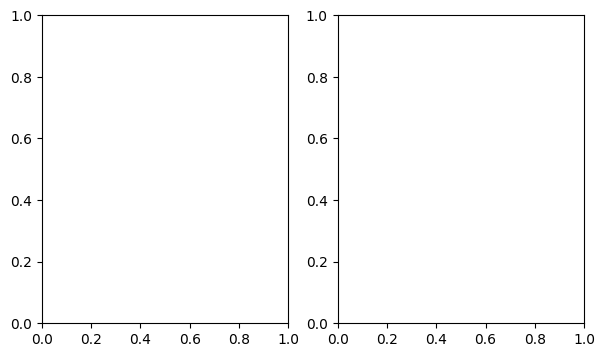

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4))

ax1.bar(np.arange(0, 2 ** n_qubits), xhat, color="blue")
ax1.set_xlim(-0.5, 2 ** n_qubits - 0.5)
ax1.set_xlabel("Vector space basis")
ax1.set_title("Classical probabilities")

ax2.bar(np.arange(0, 2 ** n_qubits), statevector, color="green")
ax2.set_xlim(-0.5, 2 ** n_qubits - 0.5)
ax2.set_xlabel("Hilbert space basis")
ax2.set_title("Quantum probabilities")

plt.show()